
# MVP Measurement System — Поступашки

## Гибридный prototype: real sales + synthetic upstream events

Цель MVP — показать **работающую end-to-end логику**:

**placement → tracking/deep link → user touch → lead → real payment → attribution → ROMI_attr → forecast-ready mart**

### Что здесь реальное, а что demo

- **REAL:** продажи и оплаты загружаются из `base.xlsx`.
- **SYNTHETIC / DEMO:** placement-level source assignment, user touches, leads, tracking links и marketing cost.
- **НЕ утверждаем:** что конкретная историческая покупка действительно пришла из назначенного demo-placement.
- **ROMI_attr:** демонстрирует, как система будет считать attributed revenue и ROMI после внедрения tracking; это не causal effect и не `ROMI_inc`.

Такой дизайн нужен потому, что в исторических данных есть реальный downstream (покупки), но нет надёжного user-level пути от рекламы до оплаты.



## 1. Архитектура MVP

В production путь должен выглядеть так:

**campaign → placement → creative → tracking/deep link → hashed user_id → lead_id → order/payment → attributed revenue → ROMI_attr**

В notebook реализована та же логика, но отсутствующие исторические upstream-события создаются как demo-events.


In [1]:

from pathlib import Path
import hashlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

def find_base_xlsx():
    candidates = [
        Path("../data/raw/base.xlsx"),   # notebook inside notebooks/
        Path("data/raw/base.xlsx"),      # notebook from repo root
        Path("base.xlsx"),               # local copy
        Path("/mnt/data/base.xlsx"),     # execution environment for this demo
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(
        "base.xlsx not found. Put it in data/raw/base.xlsx or update BASE_PATH."
    )

BASE_PATH = find_base_xlsx()
print("Using:", BASE_PATH)


Using: /mnt/data/base.xlsx



## 2. REAL layer: загружаем продажи из `base.xlsx`

Исходный файл содержит реальные обезличенные продажи.  
Мы **не генерируем оплаты и суммы**.

В данных есть неоднозначность bundle-покупок: несколько строк с одинаковым пользователем и timestamp могут относиться к одному заказу. Поэтому:

- для общего количества заказов строим **probable order** по `student_id + timestamp`;
- для attribution/ROMI demo используем только **single-row orders**, где сумма покупки не неоднозначна;
- bundle-кандидаты не используем для attributed revenue в MVP.


In [2]:

sales_raw = pd.read_excel(BASE_PATH)

sales = (
    sales_raw.rename(columns={
        "Номер студента": "student_id",
        "Сумма": "amount_rub",
        "Курс": "course",
        "Время": "payment_time",
    })
    .copy()
)

sales["payment_time"] = pd.to_datetime(sales["payment_time"])
sales["student_id"] = sales["student_id"].astype(str)
sales["user_id"] = "student_" + sales["student_id"]

print("Rows:", len(sales))
print("Unique users:", sales["student_id"].nunique())
print("Courses:", sales["course"].nunique())
print("Period:", sales["payment_time"].min(), "—", sales["payment_time"].max())

sales.head()


Rows: 795
Unique users: 606
Courses: 18
Period: 2026-08-04 09:08:31 — 2026-09-10 06:09:12


,student_id,amount_rub,course,payment_time,user_id
0,437,8950.0,ML про,2026-08-04 09:08:31,student_437
1,437,7890.0,Аналитика старт,2026-08-04 09:35:00,student_437
2,443,8475.0,Линейная алгебра,2026-08-04 10:14:38,student_443
3,443,8475.0,Мат анализ,2026-08-04 10:14:38,student_443
4,430,8950.0,К ВУЗу,2026-08-04 13:38:06,student_430


In [3]:

# Probable order = one user + one exact purchase timestamp.
# We deliberately do not force a revenue rule for bundle candidates.

order_groups = (
    sales.groupby(["student_id", "user_id", "payment_time"], as_index=False)
    .agg(
        n_course_rows=("course", "size"),
        course_list=("course", lambda s: " | ".join(sorted(s.astype(str).unique()))),
        n_unique_amounts=("amount_rub", "nunique"),
        first_amount_rub=("amount_rub", "first"),
        raw_rows_amount_sum=("amount_rub", "sum"),
    )
    .sort_values("payment_time")
    .reset_index(drop=True)
)

order_groups["order_id"] = [f"O{i:04d}" for i in range(1, len(order_groups) + 1)]
order_groups["is_bundle_candidate"] = order_groups["n_course_rows"] > 1

single_orders = order_groups[~order_groups["is_bundle_candidate"]].copy()
single_orders["course"] = single_orders["course_list"]
single_orders["order_amount_rub"] = single_orders["first_amount_rub"]

quality_summary = pd.DataFrame({
    "metric": [
        "sales rows",
        "unique users",
        "probable orders (user + exact timestamp)",
        "single-row orders usable for ROMI demo",
        "bundle-candidate orders excluded from attributed revenue demo",
    ],
    "value": [
        len(sales),
        sales["student_id"].nunique(),
        len(order_groups),
        len(single_orders),
        int(order_groups["is_bundle_candidate"].sum()),
    ],
})

quality_summary


,metric,value
0,sales rows,795
1,unique users,606
2,probable orders (user + exact timestamp),628
3,single-row orders usable for ROMI demo,475
4,bundle-candidate orders excluded from attribut...,153



## 3. DEMO marketing registry: campaign → placement → creative

В историческом sales-layer нет надёжного placement-level source и cost. Поэтому ниже — **demo registry**.

Важно:
- `creative_id` выделен отдельно;
- `tracking_payload` уникален для пары placement + creative;
- `tracking_link` показывает, как мог бы работать Telegram deep link;
- `cost_rub` — mock и используется только для проверки ROMI-calculator.


In [4]:

DEMO_BOT = "postupashki_measure_bot"

placements = pd.DataFrame([
    {
        "placement_id": "P001",
        "campaign_id": "START_AUG",
        "creative_id": "C001",
        "channel": "@zadachi_ds",
        "channel_type": "external",
        "product_line": "START",
        "published_at": "2026-08-08 10:00:00",
        "attribution_window_end": "2026-08-10 23:59:59",
        "cost_rub": 18000,
    },
    {
        "placement_id": "P002",
        "campaign_id": "PRO_AUG",
        "creative_id": "C002",
        "channel": "@ProdAnalysis",
        "channel_type": "external",
        "product_line": "PRO",
        "published_at": "2026-08-22 10:00:00",
        "attribution_window_end": "2026-08-29 23:59:59",
        "cost_rub": 30000,
    },
    {
        "placement_id": "P003",
        "campaign_id": "PRO_SEPT",
        "creative_id": "C003",
        "channel": "@chad_protocol",
        "channel_type": "external",
        "product_line": "PRO",
        "published_at": "2026-09-02 10:00:00",
        "attribution_window_end": "2026-09-04 23:59:59",
        "cost_rub": 25000,
    },
    {
        "placement_id": "P004",
        "campaign_id": "PRO_SEPT",
        "creative_id": "C004",
        "channel": "@codeof_art",
        "channel_type": "external",
        "product_line": "PRO",
        "published_at": "2026-09-05 10:00:00",
        "attribution_window_end": "2026-09-07 23:59:59",
        "cost_rub": 20000,
    },
])

placements["published_at"] = pd.to_datetime(placements["published_at"])
placements["attribution_window_end"] = pd.to_datetime(placements["attribution_window_end"])
placements["tracking_payload"] = placements["placement_id"] + "_" + placements["creative_id"]
placements["tracking_link"] = (
    "https://t.me/" + DEMO_BOT + "?start=" + placements["tracking_payload"]
)
placements["marketing_data_origin"] = "DEMO / synthetic"
placements["cost_data_origin"] = "DEMO / synthetic"

placements[[
    "campaign_id", "placement_id", "creative_id", "channel",
    "product_line", "cost_rub", "tracking_link"
]]


,campaign_id,placement_id,creative_id,channel,product_line,cost_rub,tracking_link
0,START_AUG,P001,C001,@zadachi_ds,START,18000,https://t.me/postupashki_measure_bot?start=P00...
1,PRO_AUG,P002,C002,@ProdAnalysis,PRO,30000,https://t.me/postupashki_measure_bot?start=P00...
2,PRO_SEPT,P003,C003,@chad_protocol,PRO,25000,https://t.me/postupashki_measure_bot?start=P00...
3,PRO_SEPT,P004,C004,@codeof_art,PRO,20000,https://t.me/postupashki_measure_bot?start=P00...



## 4. Как должен работать Telegram stitching

Production-механизм:

**ad/post → `t.me/bot?start=<placement_id>_<creative_id>` → bot_start → hashed Telegram user id → lead_id → payment**

Пример:

`https://t.me/postupashki_measure_bot?start=P001_C001`

При старте бот сохраняет:

- `placement_id = P001`
- `creative_id = C001`
- timestamp
- hashed Telegram user identifier

После появления лида `lead_id` наследует этот `user_id` и source.

> Если реклама ведёт просто в Telegram-канал и user-level идентификатор не передаётся, deterministic stitching невозможен. Такой трафик можно анализировать только агрегатно либо через дополнительный promo/self-reported source.

В `base.xlsx` downstream-user уже обезличен. В demo мы используем этот ID для проверки join-логики, **но не утверждаем, что исторический source действительно известен**.


In [5]:

def demo_hash(value: str, salt: str = "postupashki-demo") -> str:
    return hashlib.sha256(f"{salt}:{value}".encode("utf-8")).hexdigest()[:16]

tracking_example = placements[[
    "placement_id", "creative_id", "tracking_payload", "tracking_link"
]].copy()

tracking_example["example_hashed_user_id"] = [
    demo_hash(f"telegram-user-{i}") for i in range(1, len(tracking_example) + 1)
]

tracking_example


,placement_id,creative_id,tracking_payload,tracking_link,example_hashed_user_id
0,P001,C001,P001_C001,https://t.me/postupashki_measure_bot?start=P00...,76cf8545fd8ca407
1,P002,C002,P002_C002,https://t.me/postupashki_measure_bot?start=P00...,b812d8d9978ee9e0
2,P003,C003,P003_C003,https://t.me/postupashki_measure_bot?start=P00...,b383f5e3e3a26e2e
3,P004,C004,P004_C004,https://t.me/postupashki_measure_bot?start=P00...,94f5f1716317456b



## 5. HYBRID layer: synthetic touches/leads + REAL payments

Теперь строим demo-funnel.

Логика:
1. Берём реальные single-row orders, которые произошли после demo-placement и соответствуют продуктовой линейке.
2. Для части реальных покупателей создаём **synthetic touch + synthetic lead**.
3. Добавляем synthetic пользователей без покупки, чтобы показать funnel.
4. Payment остаётся **реальным**: реальный курс, сумма и timestamp из `base.xlsx`.

Следовательно, source assignment остаётся demo, но downstream purchase не сгенерирован.


In [6]:

START_COURSES = {
    "ML старт", "Backend старт", "Алгоритмы старт", "Аналитика старт"
}
PRO_COURSES = {
    "AI агенты", "Backend про", "ML про", "АВ тестам",
    "Алгоритмы про", "Аналитика про"
}

touch_plan = {"P001": 70, "P002": 85, "P003": 65, "P004": 75}
lead_plan = {"P001": 19, "P002": 25, "P003": 18, "P004": 20}
paid_plan = {"P001": 7, "P002": 6, "P003": 5, "P004": 5}

selected_paid = []
used_orders = set()

for _, p in placements.iterrows():
    allowed_courses = START_COURSES if p["product_line"] == "START" else PRO_COURSES

    eligible = single_orders[
        single_orders["course"].isin(allowed_courses)
        & (single_orders["payment_time"] >= p["published_at"])
        & (single_orders["payment_time"] <= p["attribution_window_end"])
        & (~single_orders["order_id"].isin(used_orders))
    ].copy()

    n = min(paid_plan[p["placement_id"]], len(eligible))
    sample = eligible.sample(
        n=n,
        random_state=RANDOM_SEED + int(p["placement_id"][-1])
    ).copy()

    sample["placement_id"] = p["placement_id"]
    sample["creative_id"] = p["creative_id"]
    selected_paid.append(sample)
    used_orders.update(sample["order_id"])

selected_paid = pd.concat(selected_paid, ignore_index=True)

selected_paid[[
    "order_id", "user_id", "course", "order_amount_rub",
    "payment_time", "placement_id", "creative_id"
]].head(10)


,order_id,user_id,course,order_amount_rub,payment_time,placement_id,creative_id
0,O0082,student_53,ML старт,4950.00,2026-08-09 13:57:35,P001,C001
1,O0040,student_265,ML старт,5990.00,2026-08-08 16:25:28,P001,C001
2,O0117,student_369,Алгоритмы старт,4495.00,2026-08-09 18:53:23,P001,C001
3,O0105,student_380,ML старт,6490.00,2026-08-09 17:19:11,P001,C001
4,O0074,student_232,Аналитика старт,6490.00,2026-08-09 10:47:20,P001,C001
5,O0157,student_389,Аналитика старт,5990.00,2026-08-10 19:12:23,P001,C001
6,O0094,student_550,Алгоритмы старт,5463.34,2026-08-09 16:24:42,P001,C001
7,O0246,student_248,ML про,7475.00,2026-08-22 13:43:42,P002,C002
8,O0240,student_370,Backend про,5750.00,2026-08-22 11:14:12,P002,C002
9,O0328,student_463,ML про,8950.00,2026-08-25 13:16:31,P002,C002


In [7]:

touch_rows = []
lead_rows = []
lead_lookup = {}

for _, p in placements.iterrows():
    pid = p["placement_id"]
    cid = p["creative_id"]
    paid_users = selected_paid[selected_paid["placement_id"].eq(pid)].copy()

    # 1) Real downstream purchasers: synthetic upstream events linked to their anonymized real user_id.
    for _, order in paid_users.iterrows():
        lead_id = f"L_{pid}_{len(lead_rows)+1:03d}"
        touch_id = f"T_{pid}_{len(touch_rows)+1:03d}"

        latest_touch = min(
            order["payment_time"] - pd.Timedelta(hours=2),
            p["published_at"] + pd.Timedelta(hours=24)
        )
        touch_time = max(p["published_at"], latest_touch)

        touch_rows.append({
            "touch_id": touch_id,
            "user_id": order["user_id"],
            "placement_id": pid,
            "creative_id": cid,
            "touch_time": touch_time,
            "event_origin": "SYNTHETIC upstream event",
            "user_origin": "REAL anonymized purchaser from base.xlsx",
        })

        lead_rows.append({
            "lead_id": lead_id,
            "user_id": order["user_id"],
            "placement_id": pid,
            "creative_id": cid,
            "product_interest": order["course"],
            "lead_created_at": touch_time + pd.Timedelta(hours=1),
            "status": "paid",
            "event_origin": "SYNTHETIC upstream event",
        })

        lead_lookup[(pid, order["order_id"])] = lead_id

    # 2) Add synthetic leads without payments.
    current_leads = len(paid_users)
    for j in range(current_leads, lead_plan[pid]):
        user_id = f"demo_lead_{pid}_{j:03d}"
        touch_id = f"T_{pid}_{len(touch_rows)+1:03d}"
        lead_id = f"L_{pid}_{len(lead_rows)+1:03d}"
        touch_time = p["published_at"] + pd.Timedelta(
            hours=int(rng.integers(0, 48))
        )

        touch_rows.append({
            "touch_id": touch_id,
            "user_id": user_id,
            "placement_id": pid,
            "creative_id": cid,
            "touch_time": touch_time,
            "event_origin": "SYNTHETIC upstream event",
            "user_origin": "SYNTHETIC non-purchaser",
        })

        lead_rows.append({
            "lead_id": lead_id,
            "user_id": user_id,
            "placement_id": pid,
            "creative_id": cid,
            "product_interest": p["product_line"],
            "lead_created_at": touch_time + pd.Timedelta(hours=1),
            "status": "new",
            "event_origin": "SYNTHETIC upstream event",
        })

    # 3) Add touch-only synthetic users until planned touch volume is reached.
    created_for_pid = sum(1 for x in touch_rows if x["placement_id"] == pid)
    for j in range(created_for_pid, touch_plan[pid]):
        user_id = f"demo_touch_{pid}_{j:03d}"
        touch_rows.append({
            "touch_id": f"T_{pid}_{len(touch_rows)+1:03d}",
            "user_id": user_id,
            "placement_id": pid,
            "creative_id": cid,
            "touch_time": p["published_at"] + pd.Timedelta(
                hours=int(rng.integers(0, 72))
            ),
            "event_origin": "SYNTHETIC upstream event",
            "user_origin": "SYNTHETIC non-lead",
        })

touches = pd.DataFrame(touch_rows)
leads = pd.DataFrame(lead_rows)

payments = selected_paid.copy()
payments["lead_id"] = payments.apply(
    lambda r: lead_lookup[(r["placement_id"], r["order_id"])], axis=1
)
payments["payment_id"] = [f"PAY{i:03d}" for i in range(1, len(payments) + 1)]
payments["payment_data_origin"] = "REAL base.xlsx"
payments["amount_rub"] = payments["order_amount_rub"]

print("Synthetic touches:", len(touches))
print("Synthetic leads:", len(leads))
print("REAL payments used in attribution demo:", len(payments))

payments[[
    "payment_id", "order_id", "lead_id", "user_id",
    "course", "amount_rub", "payment_time",
    "placement_id", "payment_data_origin"
]].head()


Synthetic touches: 295
Synthetic leads: 82
REAL payments used in attribution demo: 23


,payment_id,order_id,lead_id,user_id,course,amount_rub,payment_time,placement_id,payment_data_origin
0,PAY001,O0082,L_P001_001,student_53,ML старт,4950.0,2026-08-09 13:57:35,P001,REAL base.xlsx
1,PAY002,O0040,L_P001_002,student_265,ML старт,5990.0,2026-08-08 16:25:28,P001,REAL base.xlsx
2,PAY003,O0117,L_P001_003,student_369,Алгоритмы старт,4495.0,2026-08-09 18:53:23,P001,REAL base.xlsx
3,PAY004,O0105,L_P001_004,student_380,ML старт,6490.0,2026-08-09 17:19:11,P001,REAL base.xlsx
4,PAY005,O0074,L_P001_005,student_232,Аналитика старт,6490.0,2026-08-09 10:47:20,P001,REAL base.xlsx



## 6. User stitching: payment → lead → touch → placement → creative

Это ключевая проверка MVP: разные сущности реально соединяются ключами.

**Важно:** join технически рабочий, но upstream source для исторических real payments назначен искусственно только для demo.


In [8]:

journey = (
    payments[[
        "payment_id", "order_id", "lead_id", "user_id",
        "course", "amount_rub", "payment_time", "payment_data_origin"
    ]]
    .merge(
        leads[[
            "lead_id", "user_id", "placement_id", "creative_id",
            "product_interest", "lead_created_at", "event_origin"
        ]],
        on=["lead_id", "user_id"],
        how="left",
        validate="one_to_one",
    )
    .merge(
        touches[[
            "user_id", "placement_id", "creative_id",
            "touch_id", "touch_time", "user_origin"
        ]],
        on=["user_id", "placement_id", "creative_id"],
        how="left",
        validate="one_to_one",
    )
    .merge(
        placements[[
            "placement_id", "campaign_id", "creative_id", "channel",
            "product_line", "cost_rub", "tracking_payload"
        ]],
        on=["placement_id", "creative_id"],
        how="left",
        validate="many_to_one",
    )
)

journey[[
    "payment_id", "order_id", "user_id", "touch_id", "lead_id",
    "placement_id", "creative_id", "course", "amount_rub",
    "payment_data_origin"
]].head(10)


,payment_id,order_id,user_id,touch_id,lead_id,placement_id,creative_id,course,amount_rub,payment_data_origin
0,PAY001,O0082,student_53,T_P001_001,L_P001_001,P001,C001,ML старт,4950.00,REAL base.xlsx
1,PAY002,O0040,student_265,T_P001_002,L_P001_002,P001,C001,ML старт,5990.00,REAL base.xlsx
2,PAY003,O0117,student_369,T_P001_003,L_P001_003,P001,C001,Алгоритмы старт,4495.00,REAL base.xlsx
3,PAY004,O0105,student_380,T_P001_004,L_P001_004,P001,C001,ML старт,6490.00,REAL base.xlsx
4,PAY005,O0074,student_232,T_P001_005,L_P001_005,P001,C001,Аналитика старт,6490.00,REAL base.xlsx
5,PAY006,O0157,student_389,T_P001_006,L_P001_006,P001,C001,Аналитика старт,5990.00,REAL base.xlsx
6,PAY007,O0094,student_550,T_P001_007,L_P001_007,P001,C001,Алгоритмы старт,5463.34,REAL base.xlsx
7,PAY008,O0246,student_248,T_P002_071,L_P002_020,P002,C002,ML про,7475.00,REAL base.xlsx
8,PAY009,O0240,student_370,T_P002_072,L_P002_021,P002,C002,Backend про,5750.00,REAL base.xlsx
9,PAY010,O0328,student_463,T_P002_073,L_P002_022,P002,C002,ML про,8950.00,REAL base.xlsx



## 7. Attribution + ROMI calculator

Attribution rule v1:

> payment получает source того `placement_id`, который записан у соответствующего lead.

В production data model может хранить несколько touches, а поверх неё можно сравнивать first-touch / last-touch / linear / time-decay.

Здесь:

\[
ROMI_{attr} = \frac{Attributed\ Revenue - Marketing\ Cost}{Marketing\ Cost}
\]

- revenue — из **реальных single-row purchases**;
- source и marketing cost — **demo**;
- поэтому итоговый ROMI — **демонстрационный результат работы calculator**, а не историческая оценка эффективности канала.


In [9]:

touch_stats = (
    touches.groupby("placement_id", as_index=False)
    .agg(touches=("touch_id", "nunique"))
)

lead_stats = (
    leads.groupby("placement_id", as_index=False)
    .agg(leads=("lead_id", "nunique"))
)

payment_stats = (
    journey.groupby("placement_id", as_index=False)
    .agg(
        purchases=("payment_id", "nunique"),
        attributed_revenue=("amount_rub", "sum"),
    )
)

romi_table = (
    placements
    .merge(touch_stats, on="placement_id", how="left")
    .merge(lead_stats, on="placement_id", how="left")
    .merge(payment_stats, on="placement_id", how="left")
)

for col in ["touches", "leads", "purchases", "attributed_revenue"]:
    romi_table[col] = romi_table[col].fillna(0)

romi_table["touch_to_lead_cr"] = np.where(
    romi_table["touches"] > 0,
    romi_table["leads"] / romi_table["touches"],
    np.nan,
)

romi_table["lead_to_purchase_cr"] = np.where(
    romi_table["leads"] > 0,
    romi_table["purchases"] / romi_table["leads"],
    np.nan,
)

romi_table["cpl_rub"] = np.where(
    romi_table["leads"] > 0,
    romi_table["cost_rub"] / romi_table["leads"],
    np.nan,
)

romi_table["cac_rub"] = np.where(
    romi_table["purchases"] > 0,
    romi_table["cost_rub"] / romi_table["purchases"],
    np.nan,
)

romi_table["romi_attr"] = np.where(
    romi_table["cost_rub"] > 0,
    (romi_table["attributed_revenue"] - romi_table["cost_rub"])
    / romi_table["cost_rub"],
    np.nan,
)

romi_table["evidence_status"] = "DEMO source/cost + REAL payment"

display_cols = [
    "placement_id", "creative_id", "channel", "product_line",
    "touches", "leads", "purchases", "attributed_revenue",
    "cost_rub", "touch_to_lead_cr", "lead_to_purchase_cr",
    "cpl_rub", "cac_rub", "romi_attr", "evidence_status"
]

romi_table[display_cols].round(3)


,placement_id,creative_id,channel,product_line,touches,leads,purchases,attributed_revenue,cost_rub,touch_to_lead_cr,lead_to_purchase_cr,cpl_rub,cac_rub,romi_attr,evidence_status
0,P001,C001,@zadachi_ds,START,70,19,7,39868.34,18000,0.271,0.368,947.368,2571.429,1.215,DEMO source/cost + REAL payment
1,P002,C002,@ProdAnalysis,PRO,85,25,6,47525.00,30000,0.294,0.240,1200.000,5000.000,0.584,DEMO source/cost + REAL payment
2,P003,C003,@chad_protocol,PRO,65,18,5,44250.00,25000,0.277,0.278,1388.889,5000.000,0.770,DEMO source/cost + REAL payment
3,P004,C004,@codeof_art,PRO,75,20,5,43750.00,20000,0.267,0.250,1000.000,4000.000,1.188,DEMO source/cost + REAL payment


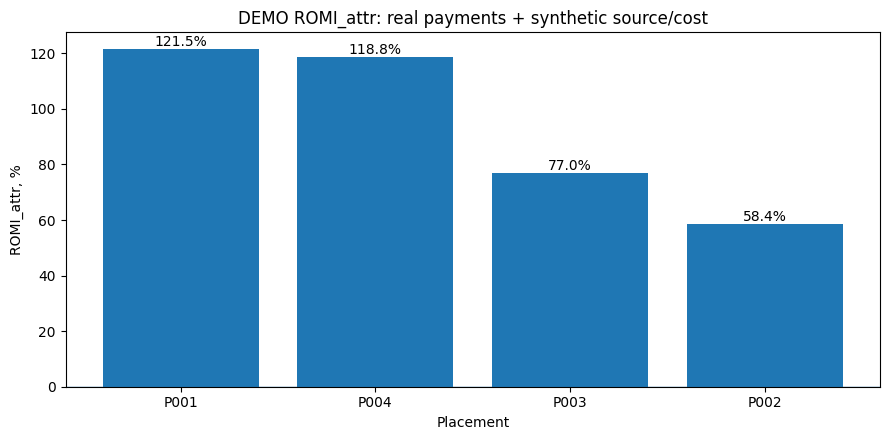

In [10]:

plot_df = romi_table.sort_values("romi_attr", ascending=False).copy()

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(plot_df["placement_id"], plot_df["romi_attr"] * 100)
ax.axhline(0, linewidth=1)
ax.set_title("DEMO ROMI_attr: real payments + synthetic source/cost")
ax.set_ylabel("ROMI_attr, %")
ax.set_xlabel("Placement")

for bar, value in zip(bars, plot_df["romi_attr"] * 100):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom" if value >= 0 else "top",
    )

plt.tight_layout()
plt.show()



## 8. Decision layer: не «раздать 300 000 ₽», а поддержать решение

MVP **не рекомендует конкретные суммы бюджета** по demo-ROMI.

Вместо этого measurement system должна поддерживать цикл:

**measure → rank → reserve test budget → run holdout/A-B → update estimates → reallocate**

То есть текущий `ROMI_attr` — сигнал для следующего теста, а не доказательство, что канал сохранит ту же отдачу при увеличении spend.


In [11]:

decision_table = (
    romi_table[[
        "placement_id", "creative_id", "channel", "product_line",
        "purchases", "attributed_revenue", "cost_rub", "romi_attr"
    ]]
    .sort_values("romi_attr", ascending=False)
    .reset_index(drop=True)
)

decision_table["demo_rank"] = np.arange(1, len(decision_table) + 1)
decision_table["romi_attr_pct"] = decision_table["romi_attr"] * 100
decision_table["next_action"] = np.where(
    decision_table["romi_attr"] > 0,
    "candidate for controlled retest",
    "do not scale before retest"
)

decision_table[[
    "demo_rank", "placement_id", "creative_id", "channel",
    "romi_attr_pct", "next_action"
]].round({"romi_attr_pct": 1})


,demo_rank,placement_id,creative_id,channel,romi_attr_pct,next_action
0,1,P001,C001,@zadachi_ds,121.5,candidate for controlled retest
1,2,P004,C004,@codeof_art,118.8,candidate for controlled retest
2,3,P003,C003,@chad_protocol,77.0,candidate for controlled retest
3,4,P002,C002,@ProdAnalysis,58.4,candidate for controlled retest


In [12]:

allocation_process = pd.DataFrame({
    "step": [1, 2, 3, 4, 5, 6],
    "decision_stage": [
        "Measure",
        "Rank",
        "Reserve test budget",
        "Run holdout / A-B",
        "Update estimates",
        "Reallocate",
    ],
    "what_system_uses": [
        "touches, leads, purchases, revenue, cost",
        "ROMI_attr + conversion + CAC/CPL",
        "uncertainty + business constraints",
        "incremental lift",
        "new evidence",
        "ROMI_attr + ROMI_inc + forecast",
    ],
})

allocation_process


,step,decision_stage,what_system_uses
0,1,Measure,"touches, leads, purchases, revenue, cost"
1,2,Rank,ROMI_attr + conversion + CAC/CPL
2,3,Reserve test budget,uncertainty + business constraints
3,4,Run holdout / A-B,incremental lift
4,5,Update estimates,new evidence
5,6,Reallocate,ROMI_attr + ROMI_inc + forecast



## 9. Forecast-ready mart

Для прогноза мы не хотим обучаться на выдуманных purchases. Поэтому target-layer строим из **всех реальных probable orders** в `base.xlsx`.

Из-за bundle-неоднозначности первой целевой метрикой выбираем:

**number of probable paid orders per day**

а не revenue.

Marketing features в текущем notebook остаются demo. После production-внедрения те же поля будут заполняться реальными tracking/logging events.


In [13]:

real_orders_daily = (
    order_groups.assign(date=order_groups["payment_time"].dt.normalize())
    .groupby("date", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        buyers=("student_id", "nunique"),
        bundle_candidate_orders=("is_bundle_candidate", "sum"),
    )
)

touches_daily = (
    touches.assign(date=touches["touch_time"].dt.normalize())
    .groupby("date", as_index=False)
    .agg(demo_touches=("touch_id", "nunique"))
)

leads_daily = (
    leads.assign(date=leads["lead_created_at"].dt.normalize())
    .groupby("date", as_index=False)
    .agg(demo_leads=("lead_id", "nunique"))
)

placement_days = []
for _, p in placements.iterrows():
    days = pd.date_range(
        p["published_at"].normalize(),
        p["attribution_window_end"].normalize(),
        freq="D",
    )
    for d in days:
        placement_days.append({
            "date": d,
            "placement_id": p["placement_id"],
            "channel": p["channel"],
        })

placement_days = pd.DataFrame(placement_days)

active_placements_daily = (
    placement_days.groupby("date", as_index=False)
    .agg(
        demo_active_placements=("placement_id", "nunique"),
        demo_unique_channels=("channel", "nunique"),
    )
)

spend_daily = (
    placements.assign(date=placements["published_at"].dt.normalize())
    .groupby("date", as_index=False)
    .agg(demo_planned_spend=("cost_rub", "sum"))
)

calendar = pd.DataFrame({
    "date": pd.date_range(
        order_groups["payment_time"].min().normalize(),
        order_groups["payment_time"].max().normalize(),
        freq="D",
    )
})

forecast_mart = (
    calendar
    .merge(real_orders_daily, on="date", how="left")
    .merge(touches_daily, on="date", how="left")
    .merge(leads_daily, on="date", how="left")
    .merge(active_placements_daily, on="date", how="left")
    .merge(spend_daily, on="date", how="left")
)

fill_zero = [
    "orders", "buyers", "bundle_candidate_orders",
    "demo_touches", "demo_leads",
    "demo_active_placements", "demo_unique_channels",
    "demo_planned_spend",
]
forecast_mart[fill_zero] = forecast_mart[fill_zero].fillna(0)

forecast_mart["day_of_week"] = forecast_mart["date"].dt.dayofweek
forecast_mart["orders_lag_1"] = forecast_mart["orders"].shift(1)
forecast_mart["orders_roll_7"] = (
    forecast_mart["orders"].shift(1).rolling(7, min_periods=1).mean()
)

forecast_mart["sales_target_origin"] = "REAL base.xlsx"
forecast_mart["marketing_features_origin"] = "DEMO / synthetic in MVP"

forecast_mart.head(12)


,date,orders,buyers,bundle_candidate_orders,demo_touches,demo_leads,demo_active_placements,demo_unique_channels,demo_planned_spend,day_of_week,orders_lag_1,orders_roll_7,sales_target_origin,marketing_features_origin
0,2026-08-04,7,6,2,0.0,0.0,0.0,0.0,0.0,1,NaN,NaN,REAL base.xlsx,DEMO / synthetic in MVP
1,2026-08-05,6,6,2,0.0,0.0,0.0,0.0,0.0,2,7.0,7.000000,REAL base.xlsx,DEMO / synthetic in MVP
2,2026-08-06,7,7,1,0.0,0.0,0.0,0.0,0.0,3,6.0,6.500000,REAL base.xlsx,DEMO / synthetic in MVP
3,2026-08-07,5,5,1,0.0,0.0,0.0,0.0,0.0,4,7.0,6.666667,REAL base.xlsx,DEMO / synthetic in MVP
4,2026-08-08,35,35,14,13.0,5.0,1.0,1.0,18000.0,5,5.0,6.250000,REAL base.xlsx,DEMO / synthetic in MVP
5,2026-08-09,68,68,23,28.0,11.0,1.0,1.0,0.0,6,35.0,12.000000,REAL base.xlsx,DEMO / synthetic in MVP
6,2026-08-10,29,29,6,24.0,3.0,1.0,1.0,0.0,0,68.0,21.333333,REAL base.xlsx,DEMO / synthetic in MVP
7,2026-08-11,12,12,5,5.0,0.0,0.0,0.0,0.0,1,29.0,22.428571,REAL base.xlsx,DEMO / synthetic in MVP
8,2026-08-12,14,14,3,0.0,0.0,0.0,0.0,0.0,2,12.0,23.142857,REAL base.xlsx,DEMO / synthetic in MVP
9,2026-08-13,9,9,0,0.0,0.0,0.0,0.0,0.0,3,14.0,24.285714,REAL base.xlsx,DEMO / synthetic in MVP



## 10. Что теперь реально доказывает MVP

### Реализовано

- real sales ingestion из `base.xlsx`;
- probable order layer с явной обработкой bundle-неоднозначности;
- campaign / placement / **creative_id** registry;
- demo Telegram deep-link tracking;
- touch + lead schema;
- user stitching по ключам;
- real payment linking;
- single-source attribution engine;
- attributed revenue;
- CPL / CAC / conversions;
- ROMI_attr calculator;
- decision table;
- forecast-ready mart с **real sales target**.

### Что остаётся synthetic / будущей интеграцией

- фактические historical touches;
- фактические historical leads;
- достоверный placement source для прошлых покупок;
- реальные placement costs;
- production Telegram bot / CRM / payment webhook;
- multi-touch attribution;
- causal incrementality и `ROMI_inc`.

### Главная защита от неправильной интерпретации

**REAL PAYMENT ≠ REAL HISTORICAL ATTRIBUTION.**

MVP доказывает, что предложенная data model и расчётная цепочка работают end-to-end.  
Для исторических данных upstream source отсутствует, поэтому source assignment здесь используется только для демонстрации механизма.



## 11. Как показать MVP на защите

**Сейчас:**

`ad → ??? → ??? → real payment`

**После внедрения measurement system:**

`placement_id → creative_id → tracking/deep link → hashed user_id → lead_id → payment → attribution → ROMI_attr`

Короткая формулировка:

> Мы сохранили реальный слой продаж из `base.xlsx`, а synthetic events используем только там, где исходно отсутствует user-level marketing history. Поэтому notebook не выдаёт demo-source за факт, но показывает работающую связку данных от placement до реальной оплаты и готовит структуру для production attribution, ROMI и прогнозов.
